In [1]:
print("hello")

hello


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [3]:
%pip install numpy pandas matplotlib

  Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.5.2-cp312-cp312-win_amd64.whl (12.5 MB)
Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl (9.8 MB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-n


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = np.loadtxt("data/d04_te.dat")
print(data.shape)

(960, 52)


In [6]:
columns = (
    [f"xmeas_{i}" for i in range(1, 42)]
    + [f"xmv_{i}" for i in range(1, 12)]
)

df = pd.DataFrame(data, columns=columns)

df.head()

,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.25185,3634.3,4527.3,9.3651,26.641,42.694,2705.6,75.649,120.40,0.33406,...,53.765,24.513,62.411,21.888,40.437,34.127,46.560,47.564,40.623,17.314
1,0.24938,3663.7,4494.0,9.3847,26.809,42.434,2705.4,74.546,120.43,0.33243,...,54.163,24.756,62.709,22.457,40.636,40.032,41.592,47.442,41.354,16.381
2,0.25162,3643.7,4484.5,9.3197,27.319,42.231,2704.0,74.461,120.38,0.33558,...,54.277,24.543,59.878,22.143,40.250,35.760,47.191,47.561,40.754,22.871
3,0.25019,3648.7,4488.4,9.3639,26.955,42.573,2703.9,75.036,120.43,0.33855,...,54.230,24.684,60.546,22.027,39.888,35.828,47.661,47.351,41.427,15.460
4,0.24848,3658.1,4543.2,9.3925,26.920,42.278,2705.6,75.737,120.38,0.35306,...,54.495,24.383,60.414,22.333,41.991,43.347,47.619,47.390,40.140,17.464


In [7]:
print(df.shape)
print(df.isnull().sum().sum())

(960, 52)
0


In [8]:
df["time_h"] = np.arange(len(df)) * 3 / 60

In [9]:
df[["time_h", "xmeas_9"]].head()

,time_h,xmeas_9
0,0.00,120.40
1,0.05,120.43
2,0.10,120.38
3,0.15,120.43
4,0.20,120.38


In [10]:
df["xmeas_9"].describe()

count    960.000000
mean     120.400583
std        0.019824
min      120.340000
25%      120.390000
50%      120.400000
75%      120.410000
max      120.600000
Name: xmeas_9, dtype: float64

In [11]:
df.loc[155:165, ["time_h", "xmeas_9"]]

,time_h,xmeas_9
155,7.75,120.41
156,7.80,120.38
157,7.85,120.39
158,7.90,120.38
159,7.95,120.37
160,8.00,120.60
161,8.05,120.40
162,8.10,120.45
163,8.15,120.44
164,8.20,120.40


In [12]:
df.loc[155:165, ["time_h", "xmeas_9", "xmv_10"]]

,time_h,xmeas_9,xmv_10
155,7.75,120.41,41.991
156,7.80,120.38,40.444
157,7.85,120.39,41.804
158,7.90,120.38,40.819
159,7.95,120.37,40.694
160,8.00,120.60,47.248
161,8.05,120.40,43.966
162,8.10,120.45,45.329
163,8.15,120.44,45.103
164,8.20,120.40,44.911


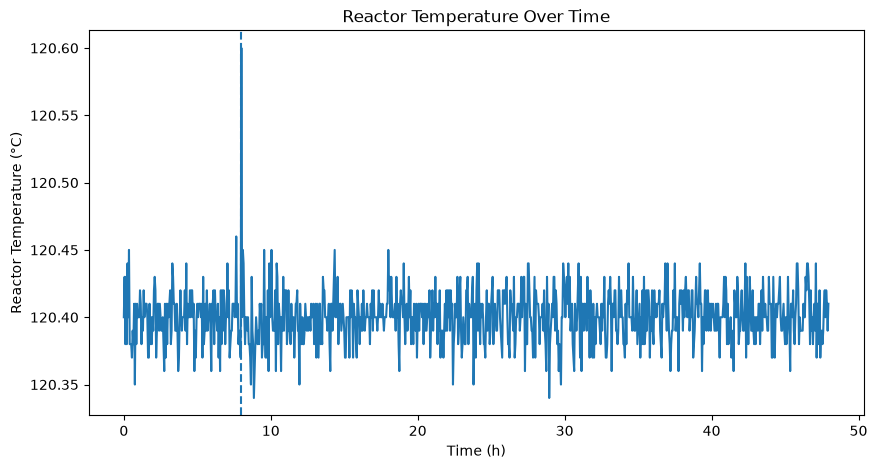

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_h"], df["xmeas_9"])

plt.axvline(8, linestyle="--")

plt.xlabel("Time (h)")
plt.ylabel("Reactor Temperature (°C)")
plt.title("Reactor Temperature Over Time")

plt.savefig("images/01_reactor_temperature.png", dpi=150, bbox_inches="tight")

plt.show()

In [15]:
df["temp_ma_30m"] = df["xmeas_9"].rolling(10).mean()

In [16]:
df[["time_h", "xmeas_9", "temp_ma_30m"]].head(15)

,time_h,xmeas_9,temp_ma_30m
0,0.00,120.40,NaN
1,0.05,120.43,NaN
2,0.10,120.38,NaN
3,0.15,120.43,NaN
4,0.20,120.38,NaN
5,0.25,120.44,NaN
6,0.30,120.40,NaN
7,0.35,120.45,NaN
8,0.40,120.38,NaN
9,0.45,120.38,120.407


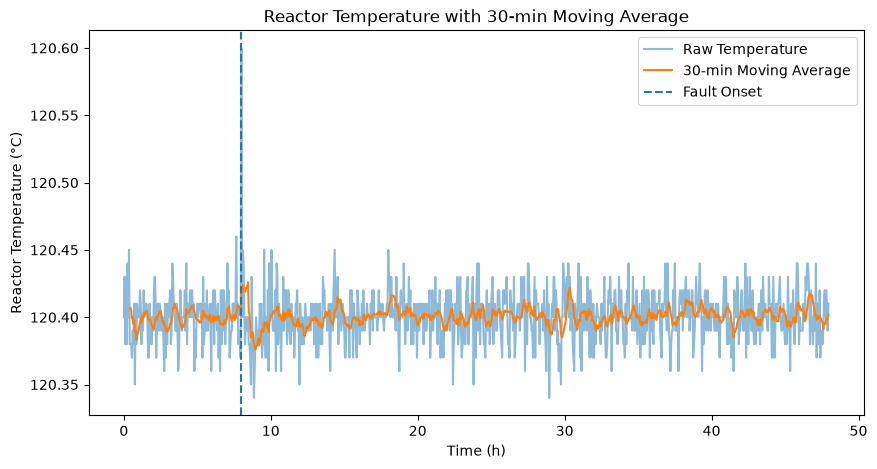

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["time_h"],
    df["xmeas_9"],
    alpha=0.5,
    label="Raw Temperature"
)

plt.plot(
    df["time_h"],
    df["temp_ma_30m"],
    label="30-min Moving Average"
)

plt.axvline(8, linestyle="--", label="Fault Onset")

plt.xlabel("Time (h)")
plt.ylabel("Reactor Temperature (°C)")
plt.title("Reactor Temperature with 30-min Moving Average")

plt.legend()

plt.savefig("images/02_moving_average.png", dpi=150, bbox_inches="tight")

plt.show()

In [19]:
df["temp_change"] = df["xmeas_9"].diff()

In [20]:
df.loc[155:165, ["time_h", "xmeas_9", "temp_change"]]

,time_h,xmeas_9,temp_change
155,7.75,120.41,0.01
156,7.80,120.38,-0.03
157,7.85,120.39,0.01
158,7.90,120.38,-0.01
159,7.95,120.37,-0.01
160,8.00,120.60,0.23
161,8.05,120.40,-0.20
162,8.10,120.45,0.05
163,8.15,120.44,-0.01
164,8.20,120.40,-0.04


In [21]:
df["abs_temp_change"] = df["temp_change"].abs()

df.nlargest(5, "abs_temp_change")[
    ["time_h", "xmeas_9", "temp_change"]
]

,time_h,xmeas_9,temp_change
160,8.00,120.60,0.23
161,8.05,120.40,-0.20
174,8.70,120.43,0.08
476,23.80,120.35,-0.08
198,9.90,120.44,0.08


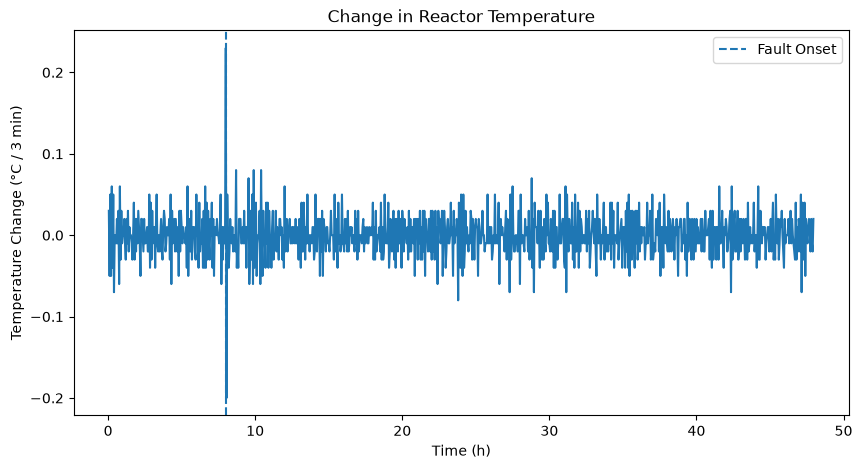

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_h"], df["temp_change"])

plt.axvline(8, linestyle="--", label="Fault Onset")

plt.xlabel("Time (h)")
plt.ylabel("Temperature Change (°C / 3 min)")
plt.title("Change in Reactor Temperature")

plt.legend()

plt.savefig("images/03_temperature_change.png", dpi=150, bbox_inches="tight")

plt.show()

In [24]:
fault_zone = df[
    (df["time_h"] >= 7.5) &
    (df["time_h"] <= 10)
]

In [25]:
fault_zone[["time_h", "xmeas_9", "xmv_10"]].head()

,time_h,xmeas_9,xmv_10
150,7.50,120.41,41.748
151,7.55,120.40,40.700
152,7.60,120.41,42.296
153,7.65,120.46,42.060
154,7.70,120.40,41.412


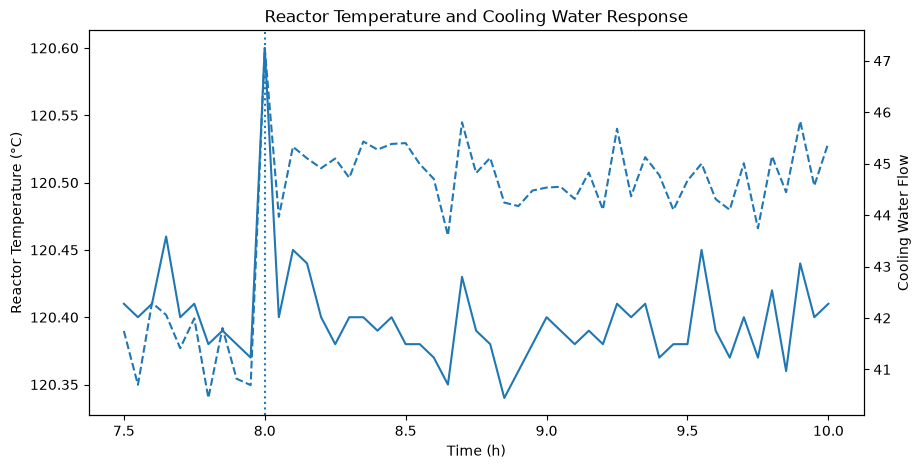

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    fault_zone["time_h"],
    fault_zone["xmeas_9"],
    label="Reactor Temperature"
)

ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Reactor Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    fault_zone["time_h"],
    fault_zone["xmv_10"],
    linestyle="--",
    label="Cooling Water Flow"
)

ax2.set_ylabel("Cooling Water Flow")

ax1.axvline(8, linestyle=":")

plt.title("Reactor Temperature and Cooling Water Response")

plt.savefig("images/04_control_response.png", dpi=150, bbox_inches="tight")

plt.show()

In [29]:
normal = df[df["time_h"] < 8]
fault = df[df["time_h"] >= 8]

normal_flow_mean = normal["xmv_10"].mean()
fault_flow_mean = fault["xmv_10"].mean()

print("Normal cooling water flow mean:", normal_flow_mean)
print("Fault cooling water flow mean:", fault_flow_mean)

increase_rate = (
    (fault_flow_mean - normal_flow_mean)
    / normal_flow_mean
    * 100
)

print("Increase rate:", increase_rate, "%")

Normal cooling water flow mean: 41.142424999999996
Fault cooling water flow mean: 44.892222499999995
Increase rate: 9.114186876442018 %


In [30]:
flow_before = df.loc[159, "xmv_10"]
flow_fault = df.loc[160, "xmv_10"]

flow_change_rate = (
    (flow_fault - flow_before)
    / flow_before
    * 100
)

print("Before fault:", flow_before)
print("At fault:", flow_fault)
print("Immediate increase rate:", flow_change_rate, "%")

Before fault: 40.694
At fault: 47.248
Immediate increase rate: 16.1055683884602 %


In [32]:
df["temp_std_60m"] = df["xmeas_9"].rolling(20).std()
df[["time_h", "xmeas_9", "temp_std_60m"]].head(25)

,time_h,xmeas_9,temp_std_60m
0,0.00,120.40,NaN
1,0.05,120.43,NaN
2,0.10,120.38,NaN
3,0.15,120.43,NaN
4,0.20,120.38,NaN
5,0.25,120.44,NaN
6,0.30,120.40,NaN
7,0.35,120.45,NaN
8,0.40,120.38,NaN
9,0.45,120.38,NaN


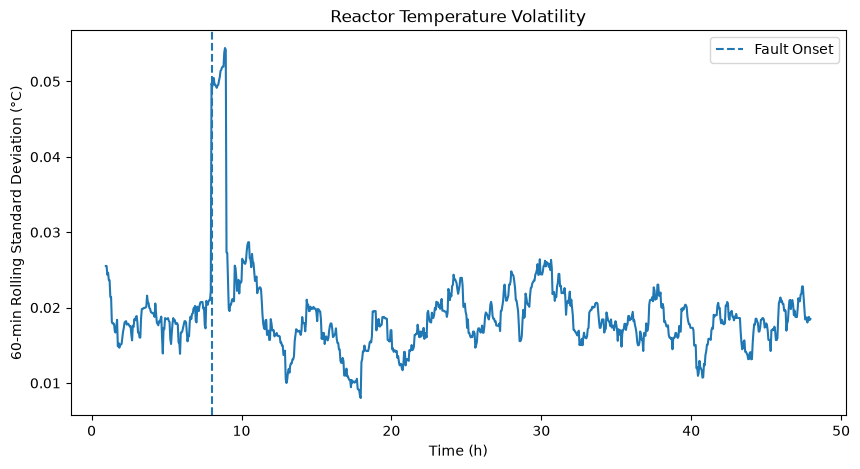

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["time_h"],
    df["temp_std_60m"]
)

plt.axvline(
    8,
    linestyle="--",
    label="Fault Onset"
)

plt.xlabel("Time (h)")
plt.ylabel("60-min Rolling Standard Deviation (°C)")
plt.title("Reactor Temperature Volatility")

plt.legend()

plt.savefig("images/05_temperature_volatility.png", dpi=150, bbox_inches="tight")

plt.show()

In [35]:
df.loc[155:180, ["time_h", "xmeas_7", "xmeas_9"]]

,time_h,xmeas_7,xmeas_9
155,7.75,2708.6,120.41
156,7.80,2710.2,120.38
157,7.85,2710.8,120.39
158,7.90,2708.9,120.38
159,7.95,2708.2,120.37
160,8.00,2711.5,120.60
161,8.05,2714.8,120.40
162,8.10,2716.6,120.45
163,8.15,2716.3,120.44
164,8.20,2712.3,120.40


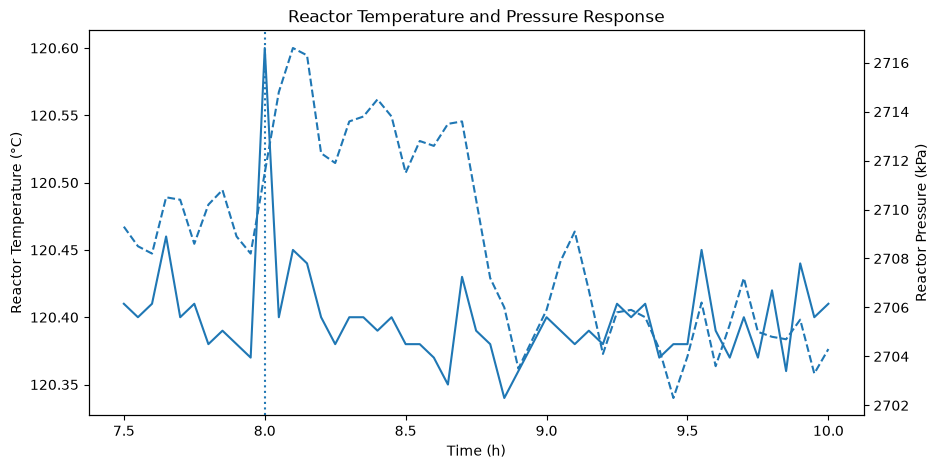

In [36]:
pressure_zone = df[
    (df["time_h"] >= 7.5) &
    (df["time_h"] <= 10)
]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    pressure_zone["time_h"],
    pressure_zone["xmeas_9"],
    label="Reactor Temperature"
)

ax1.set_xlabel("Time (h)")
ax1.set_ylabel("Reactor Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    pressure_zone["time_h"],
    pressure_zone["xmeas_7"],
    linestyle="--",
    label="Reactor Pressure"
)

ax2.set_ylabel("Reactor Pressure (kPa)")

ax1.axvline(8, linestyle=":")

plt.title("Reactor Temperature and Pressure Response")

plt.show()

In [37]:
pressure_peak = pressure_zone.loc[
    pressure_zone["xmeas_7"].idxmax(),
    ["time_h", "xmeas_7"]
]

pressure_peak

time_h        8.1
xmeas_7    2716.6
Name: 162, dtype: float64

In [38]:
temp_peak_time = df.loc[df["xmeas_9"].idxmax(), "time_h"]
pressure_peak_time = pressure_peak["time_h"]

lag_min = (pressure_peak_time - temp_peak_time) * 60

print("Temperature peak time:", temp_peak_time, "h")
print("Pressure peak time:", pressure_peak_time, "h")
print("Lag:", lag_min, "min")

Temperature peak time: 8.0 h
Pressure peak time: 8.1 h
Lag: 5.999999999999979 min


In [39]:
df["pressure_std_60m"] = df["xmeas_7"].rolling(20).std()

In [40]:
normal_pressure_std = normal["xmeas_7"].std()
fault_pressure_std = fault["xmeas_7"].std()

print("Normal pressure std:", normal_pressure_std)
print("Fault pressure std:", fault_pressure_std)

Normal pressure std: 5.133953446168107
Fault pressure std: 7.80987787936619


In [41]:
pressure_std_increase = (
    (fault_pressure_std - normal_pressure_std)
    / normal_pressure_std
    * 100
)

print("Pressure std increase:", round(pressure_std_increase, 1), "%")

Pressure std increase: 52.1 %


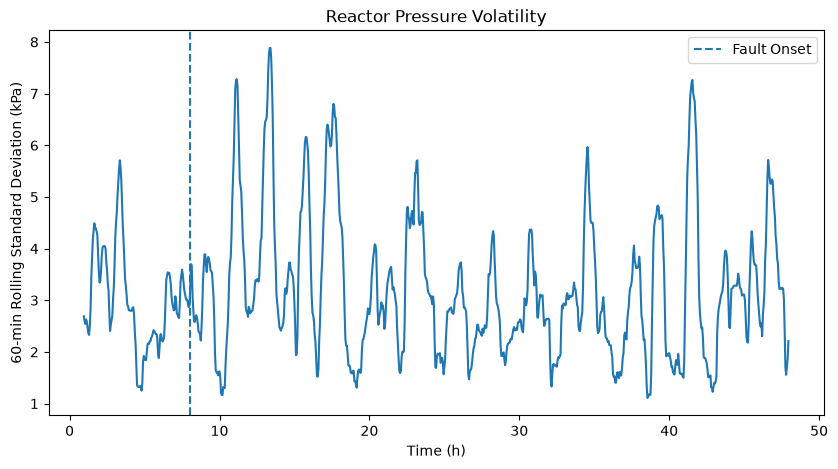

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["time_h"],
    df["pressure_std_60m"]
)

plt.axvline(
    8,
    linestyle="--",
    label="Fault Onset"
)

plt.xlabel("Time (h)")
plt.ylabel("60-min Rolling Standard Deviation (kPa)")
plt.title("Reactor Pressure Volatility")

plt.legend()

plt.savefig("images/06_pressure_volatility.png", dpi=150, bbox_inches="tight")

plt.show()

In [44]:
normal_temp_mean = normal["xmeas_9"].mean()
normal_temp_std = normal["xmeas_9"].std()

lower_limit = normal_temp_mean - 2 * normal_temp_std
upper_limit = normal_temp_mean + 2 * normal_temp_std

print("Normal mean:", normal_temp_mean)
print("Normal std:", normal_temp_std)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Normal mean: 120.3993125
Normal std: 0.01916895665838586
Lower limit: 120.36097458668323
Upper limit: 120.43765041331676


In [45]:
after_fault = df[df["time_h"] > 8]

recovered = after_fault[
    (after_fault["xmeas_9"] >= lower_limit) &
    (after_fault["xmeas_9"] <= upper_limit)
]

first_recovery_time = recovered.iloc[0]["time_h"]

recovery_minutes = (first_recovery_time - 8) * 60

print("First recovery time:", first_recovery_time, "h")
print("Recovery time:", round(recovery_minutes, 1), "min")


First recovery time: 8.05 h
Recovery time: 3.0 min


In [46]:
after_fault = df[df["time_h"] > 8].copy()

after_fault["in_normal_range"] = (
    (after_fault["xmeas_9"] >= lower_limit) &
    (after_fault["xmeas_9"] <= upper_limit)
)

In [47]:
required_samples = 10

after_fault["stable_30m"] = (
    after_fault["in_normal_range"]
    .rolling(required_samples)
    .sum()
    == required_samples
)

In [48]:
first_stable_end = after_fault.loc[
    after_fault["stable_30m"],
    "time_h"
].iloc[0]

first_stable_start = (
    first_stable_end
    - (required_samples - 1) * 3 / 60
)

settling_time_min = (
    first_stable_start - 8
) * 60

print("Stable period started:", round(first_stable_start, 2), "h")
print("30-min stability confirmed at:", round(first_stable_end, 2), "h")
print("Settling time:", round(settling_time_min, 1), "min")

Stable period started: 8.95 h
30-min stability confirmed at: 9.4 h
Settling time: 57.0 min


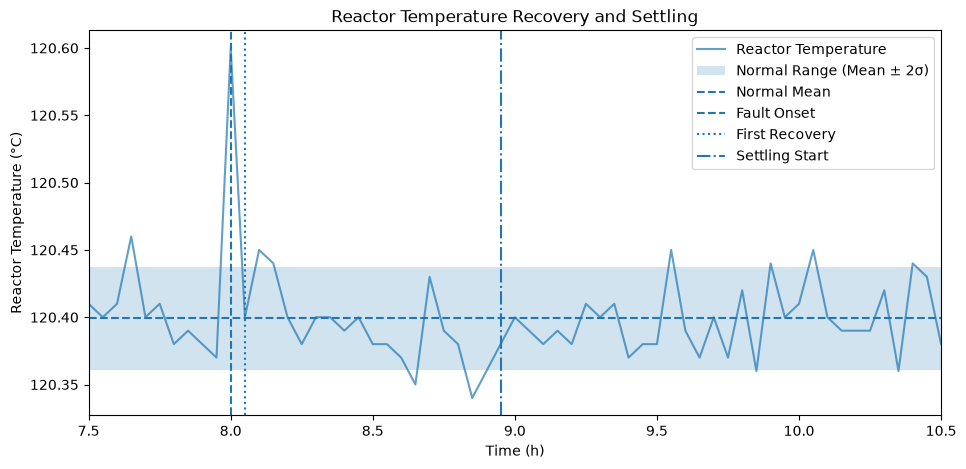

In [50]:
plt.figure(figsize=(11, 5))

plt.plot(
    df["time_h"],
    df["xmeas_9"],
    alpha=0.7,
    label="Reactor Temperature"
)

plt.axhspan(
    lower_limit,
    upper_limit,
    alpha=0.2,
    label="Normal Range (Mean ± 2σ)"
)

plt.axhline(
    normal_temp_mean,
    linestyle="--",
    label="Normal Mean"
)

plt.axvline(
    8,
    linestyle="--",
    label="Fault Onset"
)

plt.axvline(
    first_recovery_time,
    linestyle=":",
    label="First Recovery"
)

plt.axvline(
    first_stable_start,
    linestyle="-.",
    label="Settling Start"
)

plt.xlim(7.5, 10.5)

plt.xlabel("Time (h)")
plt.ylabel("Reactor Temperature (°C)")
plt.title("Reactor Temperature Recovery and Settling")

plt.legend()

plt.savefig(
    "images/07_temperature_recovery.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [51]:
normal_xmv10_mean = normal["xmv_10"].mean()

df["xmv10_deviation"] = (
    df["xmv_10"] - normal_xmv10_mean
)

df["abs_xmv10_deviation"] = (
    df["xmv10_deviation"].abs()
)

print("Normal XMV10 mean:", normal_xmv10_mean)

df.loc[
    155:165,
    ["time_h", "xmv_10", "xmv10_deviation", "abs_xmv10_deviation"]
]

Normal XMV10 mean: 41.142424999999996


,time_h,xmv_10,xmv10_deviation,abs_xmv10_deviation
155,7.75,41.991,0.848575,0.848575
156,7.80,40.444,-0.698425,0.698425
157,7.85,41.804,0.661575,0.661575
158,7.90,40.819,-0.323425,0.323425
159,7.95,40.694,-0.448425,0.448425
160,8.00,47.248,6.105575,6.105575
161,8.05,43.966,2.823575,2.823575
162,8.10,45.329,4.186575,4.186575
163,8.15,45.103,3.960575,3.960575
164,8.20,44.911,3.768575,3.768575


In [52]:
fault_2h = df[
    (df["time_h"] >= 8) &
    (df["time_h"] < 10)
].copy()

dt_h = 3 / 60

cumulative_control_deviation = (
    fault_2h["abs_xmv10_deviation"] * dt_h
).sum()

print(
    "2-hour cumulative control deviation:",
    cumulative_control_deviation
)

2-hour cumulative control deviation: 7.364350000000008


In [53]:
normal_2h_efforts = []

for start_h in [0, 2, 4, 6]:
    normal_window = df[
        (df["time_h"] >= start_h) &
        (df["time_h"] < start_h + 2)
    ]

    effort = (
        normal_window["abs_xmv10_deviation"] * dt_h
    ).sum()

    normal_2h_efforts.append(effort)

print("Normal 2-hour control deviations:")
print(normal_2h_efforts)

Normal 2-hour control deviations:
[np.float64(1.0316774999999982), np.float64(0.7592225000000017), np.float64(0.6943349999999986), np.float64(1.0479225000000012)]


In [54]:
normal_effort_mean = np.mean(normal_2h_efforts)

print(
    "Mean normal 2-hour deviation:",
    normal_effort_mean
)

Mean normal 2-hour deviation: 0.8832893749999999


In [55]:
excess_control_burden = (
    cumulative_control_deviation
    - normal_effort_mean
)

control_burden_increase = (
    excess_control_burden
    / normal_effort_mean
    * 100
)

print(
    "Fault 2-hour deviation:",
    cumulative_control_deviation
)

print(
    "Excess control burden:",
    excess_control_burden
)

print(
    "Increase from normal:",
    control_burden_increase,
    "%"
)

Fault 2-hour deviation: 7.364350000000008
Excess control burden: 6.4810606250000085
Increase from normal: 733.741490437379 %


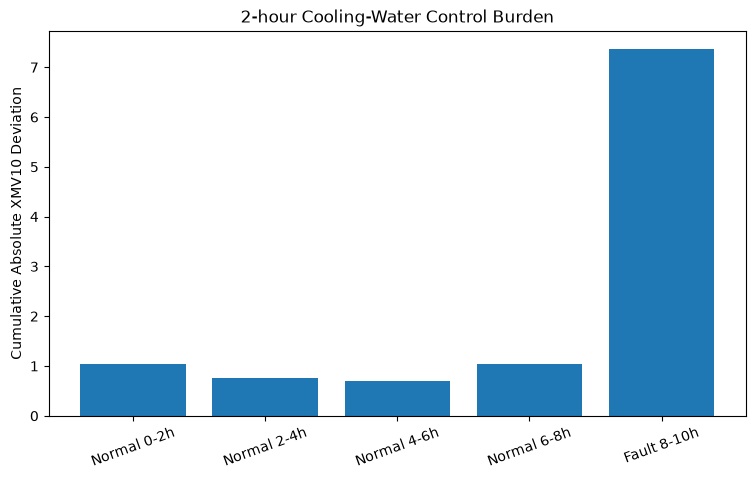

In [57]:
labels = ["Normal 0-2h", "Normal 2-4h", "Normal 4-6h", "Normal 6-8h", "Fault 8-10h"]

values = normal_2h_efforts + [cumulative_control_deviation]

plt.figure(figsize=(9, 5))
plt.bar(labels, values)

plt.ylabel("Cumulative Absolute XMV10 Deviation")
plt.title("2-hour Cooling-Water Control Burden")

plt.xticks(rotation=20)

plt.savefig(
    "images/08_control_burden.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [58]:
df["temp_error"] = (
    df["xmeas_9"] - normal_temp_mean
)

df["abs_temp_error"] = (
    df["temp_error"].abs()
)

df["squared_temp_error"] = (
    df["temp_error"] ** 2
)

df.loc[
    155:165,
    [
        "time_h",
        "xmeas_9",
        "temp_error",
        "abs_temp_error",
        "squared_temp_error"
    ]
]

,time_h,xmeas_9,temp_error,abs_temp_error,squared_temp_error
155,7.75,120.41,0.010688,0.010688,1.142227e-04
156,7.80,120.38,-0.019312,0.019312,3.729727e-04
157,7.85,120.39,-0.009312,0.009312,8.672266e-05
158,7.90,120.38,-0.019312,0.019312,3.729727e-04
159,7.95,120.37,-0.029312,0.029312,8.592227e-04
160,8.00,120.60,0.200688,0.200688,4.027547e-02
161,8.05,120.40,0.000688,0.000688,4.726563e-07
162,8.10,120.45,0.050688,0.050688,2.569223e-03
163,8.15,120.44,0.040688,0.040688,1.655473e-03
164,8.20,120.40,0.000688,0.000688,4.726563e-07


In [59]:
fault_2h = df[
    (df["time_h"] >= 8) &
    (df["time_h"] < 10)
].copy()

dt_h = 3 / 60

IAE_fault = (
    fault_2h["abs_temp_error"] * dt_h
).sum()

ISE_fault = (
    fault_2h["squared_temp_error"] * dt_h
).sum()

print("Fault 2-hour IAE:", IAE_fault)
print("Fault 2-hour ISE:", ISE_fault)

Fault 2-hour IAE: 0.049362500000002286
Fault 2-hour ISE: 0.003329757812499912


In [60]:
normal_2h_iae = []
normal_2h_ise = []

for start_h in [0, 2, 4, 6]:
    normal_window = df[
        (df["time_h"] >= start_h) &
        (df["time_h"] < start_h + 2)
    ]

    iae = (
        normal_window["abs_temp_error"] * dt_h
    ).sum()

    ise = (
        normal_window["squared_temp_error"] * dt_h
    ).sum()

    normal_2h_iae.append(iae)
    normal_2h_ise.append(ise)

print("Normal 2-hour IAE:")
print(normal_2h_iae)

print("Normal 2-hour ISE:")
print(normal_2h_ise)

Normal 2-hour IAE:
[np.float64(0.03177500000000677), np.float64(0.030637500000001695), np.float64(0.0255500000000076), np.float64(0.030843750000004635)]
Normal 2-hour ISE:
[np.float64(0.0008397578125000631), np.float64(0.0007025078124999832), np.float64(0.0005923203125000243), np.float64(0.0007866328124999808)]


In [61]:
normal_iae_mean = np.mean(normal_2h_iae)
normal_ise_mean = np.mean(normal_2h_ise)

print("Mean normal IAE:", normal_iae_mean)
print("Mean normal ISE:", normal_ise_mean)

Mean normal IAE: 0.029701562500005177
Mean normal ISE: 0.0007303046875000127


In [62]:
iae_ratio = IAE_fault / normal_iae_mean
ise_ratio = ISE_fault / normal_ise_mean

print("IAE ratio:", iae_ratio)
print("ISE ratio:", ise_ratio)

IAE ratio: 1.6619496028195042
ISE ratio: 4.559409065137425


In [63]:
lag_zone = df[
    (df["time_h"] >= 7.5) &
    (df["time_h"] <= 10)
].copy()

print(lag_zone.shape)

lag_zone[
    ["time_h", "xmeas_9", "xmeas_7"]
].head()

(51, 63)


,time_h,xmeas_9,xmeas_7
150,7.50,120.41,2709.3
151,7.55,120.40,2708.5
152,7.60,120.41,2708.2
153,7.65,120.46,2710.5
154,7.70,120.40,2710.4


In [64]:
lag_zone["pressure_shifted_6min"] = (
    lag_zone["xmeas_7"].shift(-2)
)

lag_zone.loc[
    158:165,
    [
        "time_h",
        "xmeas_9",
        "xmeas_7",
        "pressure_shifted_6min"
    ]
]

,time_h,xmeas_9,xmeas_7,pressure_shifted_6min
158,7.90,120.38,2708.9,2711.5
159,7.95,120.37,2708.2,2714.8
160,8.00,120.60,2711.5,2716.6
161,8.05,120.40,2714.8,2716.3
162,8.10,120.45,2716.6,2712.3
163,8.15,120.44,2716.3,2711.9
164,8.20,120.40,2712.3,2713.6
165,8.25,120.38,2711.9,2713.8


In [66]:
corr_0min = lag_zone["xmeas_9"].corr(
    lag_zone["xmeas_7"]
)

corr_6min = lag_zone["xmeas_9"].corr(
    lag_zone["pressure_shifted_6min"]
)

print("Correlation at 0 min lag:", corr_0min)
print("Correlation at 6 min lag:", corr_6min)

Correlation at 0 min lag: 0.24086783058205058
Correlation at 6 min lag: 0.2773298542551121


In [67]:
lag_results = []

for lag_samples in range(-10, 11):

    shifted_pressure = lag_zone["xmeas_7"].shift(
        -lag_samples
    )

    corr = lag_zone["xmeas_9"].corr(
        shifted_pressure
    )

    lag_results.append({
        "lag_samples": lag_samples,
        "lag_min": lag_samples * 3,
        "correlation": corr
    })

lag_df = pd.DataFrame(lag_results)

lag_df

,lag_samples,lag_min,correlation
0,-10,-30,-0.204573
1,-9,-27,-0.190836
2,-8,-24,-0.181290
3,-7,-21,-0.098784
4,-6,-18,-0.052998
5,-5,-15,-0.091475
6,-4,-12,-0.075066
7,-3,-9,-0.043314
8,-2,-6,-0.040874
9,-1,-3,0.052592


In [68]:
best_lag = lag_df.loc[
    lag_df["correlation"].idxmax()
]

print("Best lag:", best_lag["lag_min"], "min")
print("Maximum correlation:", best_lag["correlation"])

Best lag: 24.0 min
Maximum correlation: 0.36032118261260676


In [69]:
df["pressure_change"] = df["xmeas_7"].diff()

change_zone = df[
    (df["time_h"] >= 7.5) &
    (df["time_h"] <= 10)
].copy()

change_zone.loc[
    155:165,
    [
        "time_h",
        "temp_change",
        "pressure_change"
    ]
]

,time_h,temp_change,pressure_change
155,7.75,0.01,-1.8
156,7.80,-0.03,1.6
157,7.85,0.01,0.6
158,7.90,-0.01,-1.9
159,7.95,-0.01,-0.7
160,8.00,0.23,3.3
161,8.05,-0.20,3.3
162,8.10,0.05,1.8
163,8.15,-0.01,-0.3
164,8.20,-0.04,-4.0


In [70]:
change_lag_results = []

for lag_samples in range(-10, 11):

    shifted_pressure_change = (
        change_zone["pressure_change"]
        .shift(-lag_samples)
    )

    corr = change_zone["temp_change"].corr(
        shifted_pressure_change
    )

    change_lag_results.append({
        "lag_samples": lag_samples,
        "lag_min": lag_samples * 3,
        "correlation": corr
    })

change_lag_df = pd.DataFrame(change_lag_results)

change_lag_df

,lag_samples,lag_min,correlation
0,-10,-30,-0.108048
1,-9,-27,0.003930
2,-8,-24,-0.105073
3,-7,-21,0.053928
4,-6,-18,0.124292
5,-5,-15,-0.081517
6,-4,-12,-0.003409
7,-3,-9,0.027102
8,-2,-6,-0.146920
9,-1,-3,-0.143189


In [71]:
best_change_lag = change_lag_df.loc[
    change_lag_df["correlation"].idxmax()
]

print(
    "Best change-based lag:",
    best_change_lag["lag_min"],
    "min"
)

print(
    "Maximum change correlation:",
    best_change_lag["correlation"]
)

Best change-based lag: 0.0 min
Maximum change correlation: 0.2740359241569982


In [72]:
change_lag_df["abs_correlation"] = (
    change_lag_df["correlation"].abs()
)

strongest_change_lag = change_lag_df.loc[
    change_lag_df["abs_correlation"].idxmax()
]

print(
    "Strongest lag:",
    strongest_change_lag["lag_min"],
    "min"
)

print(
    "Correlation:",
    strongest_change_lag["correlation"]
)

print(
    "Absolute correlation:",
    strongest_change_lag["abs_correlation"]
)

Strongest lag: 0.0 min
Correlation: 0.2740359241569982
Absolute correlation: 0.2740359241569982


In [73]:
data_f14 = np.loadtxt("data/d14_te.dat")

print(data_f14.shape)

(960, 52)


In [74]:
data_f14 = np.loadtxt("data/d14_te.dat")

df_f14 = pd.DataFrame(
    data_f14,
    columns=columns
)

df_f14["time_h"] = np.arange(len(df_f14)) * 3 / 60

print(df_f14.shape)

df_f14.head()

(960, 53)


,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,time_h
0,0.25154,3681.5,4482.9,9.3026,27.009,42.339,2704.7,75.182,120.42,0.33279,...,24.544,60.721,22.311,40.592,42.855,46.951,47.524,40.525,17.025,0.00
1,0.24808,3641.1,4485.4,9.2698,27.201,42.123,2704.4,75.417,120.41,0.33468,...,24.884,60.138,22.315,40.361,44.638,46.857,47.444,41.355,15.730,0.05
2,0.25232,3678.8,4520.7,9.3886,26.836,42.448,2703.2,75.276,120.37,0.33857,...,24.474,61.813,22.022,39.886,42.374,43.048,47.385,40.521,19.064,0.10
3,0.24922,3680.0,4513.3,9.2833,26.768,42.410,2704.7,74.959,120.42,0.33700,...,24.780,61.234,22.093,40.077,35.796,48.509,47.509,41.475,17.496,0.15
4,0.24110,3660.6,4545.8,9.4511,27.139,42.409,2706.4,74.936,120.41,0.32585,...,23.575,61.853,22.577,38.456,36.699,46.098,47.657,40.584,18.915,0.20


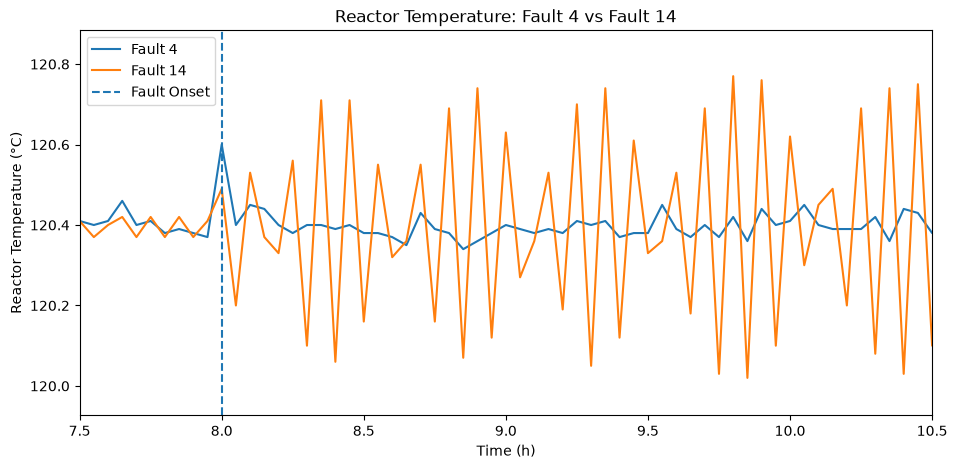

In [75]:
plt.figure(figsize=(11, 5))

plt.plot(
    df["time_h"],
    df["xmeas_9"],
    label="Fault 4"
)

plt.plot(
    df_f14["time_h"],
    df_f14["xmeas_9"],
    label="Fault 14"
)

plt.axvline(
    8,
    linestyle="--",
    label="Fault Onset"
)

plt.xlim(7.5, 10.5)

plt.xlabel("Time (h)")
plt.ylabel("Reactor Temperature (°C)")
plt.title("Reactor Temperature: Fault 4 vs Fault 14")

plt.legend()
plt.show()

In [76]:
normal_f14 = df_f14[df_f14["time_h"] < 8]

f14_temp_mean = normal_f14["xmeas_9"].mean()
f14_temp_std = normal_f14["xmeas_9"].std()

f14_lower_limit = f14_temp_mean - 2 * f14_temp_std
f14_upper_limit = f14_temp_mean + 2 * f14_temp_std

print("Fault 14 normal mean:", f14_temp_mean)
print("Fault 14 normal std:", f14_temp_std)
print("Fault 14 normal range:",
      f14_lower_limit, "~", f14_upper_limit)

Fault 14 normal mean: 120.39987500000002
Fault 14 normal std: 0.01863207149112357
Fault 14 normal range: 120.36261085701777 ~ 120.43713914298228


In [77]:
after_fault_f14 = df_f14[df_f14["time_h"] > 8].copy()

after_fault_f14["in_normal_range"] = (
    (after_fault_f14["xmeas_9"] >= f14_lower_limit) &
    (after_fault_f14["xmeas_9"] <= f14_upper_limit)
)

recovered_f14 = after_fault_f14[
    after_fault_f14["in_normal_range"]
]

first_recovery_time_f14 = recovered_f14.iloc[0]["time_h"]

recovery_minutes_f14 = (
    first_recovery_time_f14 - 8
) * 60

print(
    "Fault 14 recovery time:",
    round(recovery_minutes_f14, 1),
    "min"
)

Fault 14 recovery time: 9.0 min


In [78]:
required_samples = 10

after_fault_f14["stable_30m"] = (
    after_fault_f14["in_normal_range"]
    .rolling(required_samples)
    .sum()
    == required_samples
)

stable_rows_f14 = after_fault_f14[
    after_fault_f14["stable_30m"]
]

if len(stable_rows_f14) > 0:

    first_stable_end_f14 = (
        stable_rows_f14.iloc[0]["time_h"]
    )

    first_stable_start_f14 = (
        first_stable_end_f14
        - (required_samples - 1) * 3 / 60
    )

    settling_time_f14 = (
        first_stable_start_f14 - 8
    ) * 60

    print(
        "Fault 14 settling time:",
        round(settling_time_f14, 1),
        "min"
    )

else:
    print(
        "Fault 14 did not settle "
        "for 30 continuous minutes."
    )

Fault 14 did not settle for 30 continuous minutes.


In [79]:
fault14_2h = after_fault_f14[
    after_fault_f14["time_h"] <= 10
]

in_range_ratio_f14 = (
    fault14_2h["in_normal_range"].mean()
    * 100
)

print(
    "Fault 14 in-range ratio:",
    round(in_range_ratio_f14, 1),
    "%"
)

Fault 14 in-range ratio: 2.5 %


In [80]:
fault4_2h = after_fault[
    after_fault["time_h"] <= 10
]

in_range_ratio_f4 = (
    fault4_2h["in_normal_range"].mean()
    * 100
)

print(
    "Fault 4 in-range ratio:",
    round(in_range_ratio_f4, 1),
    "%"
)

print(
    "Fault 14 in-range ratio:",
    round(in_range_ratio_f14, 1),
    "%"
)

Fault 4 in-range ratio: 80.0 %
Fault 14 in-range ratio: 2.5 %


In [81]:
fault4_2h = df[
    (df["time_h"] >= 8) &
    (df["time_h"] < 10)
].copy()

fault14_2h = df_f14[
    (df_f14["time_h"] >= 8) &
    (df_f14["time_h"] < 10)
].copy()


fault4_2h["in_normal_range"] = (
    (fault4_2h["xmeas_9"] >= lower_limit) &
    (fault4_2h["xmeas_9"] <= upper_limit)
)

fault14_2h["in_normal_range"] = (
    (fault14_2h["xmeas_9"] >= f14_lower_limit) &
    (fault14_2h["xmeas_9"] <= f14_upper_limit)
)


f4_ratio = fault4_2h["in_normal_range"].mean() * 100
f14_ratio = fault14_2h["in_normal_range"].mean() * 100

print("Fault 4 in-range ratio:", f4_ratio, "%")
print("Fault 14 in-range ratio:", f14_ratio, "%")

Fault 4 in-range ratio: 77.5 %
Fault 14 in-range ratio: 2.5 %


In [82]:
df_f14["temp_error"] = (
    df_f14["xmeas_9"] - f14_temp_mean
)

df_f14["abs_temp_error"] = (
    df_f14["temp_error"].abs()
)

df_f14["squared_temp_error"] = (
    df_f14["temp_error"] ** 2
)

In [83]:
fault14_2h = df_f14[
    (df_f14["time_h"] >= 8) &
    (df_f14["time_h"] < 10)
].copy()

IAE_f14 = (
    fault14_2h["abs_temp_error"] * dt_h
).sum()

ISE_f14 = (
    fault14_2h["squared_temp_error"] * dt_h
).sum()

print("Fault 4 IAE:", IAE_fault)
print("Fault 14 IAE:", IAE_f14)

print("Fault 4 ISE:", ISE_fault)
print("Fault 14 ISE:", ISE_f14)

Fault 4 IAE: 0.049362500000002286
Fault 14 IAE: 0.4414750000000041
Fault 4 ISE: 0.003329757812499912
Fault 14 ISE: 0.12130190625000022


In [84]:
normal_xmv10_mean_f14 = (
    normal_f14["xmv_10"].mean()
)

df_f14["xmv10_deviation"] = (
    df_f14["xmv_10"] - normal_xmv10_mean_f14
)

df_f14["abs_xmv10_deviation"] = (
    df_f14["xmv10_deviation"].abs()
)

print(
    "Fault 14 normal XMV10 mean:",
    normal_xmv10_mean_f14
)

df_f14.loc[
    155:165,
    [
        "time_h",
        "xmv_10",
        "xmv10_deviation",
        "abs_xmv10_deviation"
    ]
]

Fault 14 normal XMV10 mean: 41.108087499999996


,time_h,xmv_10,xmv10_deviation,abs_xmv10_deviation
155,7.75,41.906,0.797913,0.797913
156,7.80,40.642,-0.466087,0.466087
157,7.85,42.367,1.258913,1.258913
158,7.90,40.871,-0.237087,0.237087
159,7.95,41.510,0.401913,0.401913
160,8.00,44.111,3.002913,3.002913
161,8.05,35.747,-5.361087,5.361087
162,8.10,45.023,3.914913,3.914913
163,8.15,40.497,-0.611087,0.611087
164,8.20,39.196,-1.912087,1.912087


In [85]:
fault14_2h = df_f14[
    (df_f14["time_h"] >= 8) &
    (df_f14["time_h"] < 10)
].copy()

control_burden_f14 = (
    fault14_2h["abs_xmv10_deviation"] * dt_h
).sum()

print("Fault 4 control burden:", cumulative_control_deviation)
print("Fault 14 control burden:", control_burden_f14)

print(
    "Fault 14 / Fault 4 ratio:",
    control_burden_f14 / cumulative_control_deviation
)

Fault 4 control burden: 7.364350000000008
Fault 14 control burden: 12.678917499999999
Fault 14 / Fault 4 ratio: 1.7216614500940322


In [86]:
normal_2h_efforts_f14 = []

for start_h in [0, 2, 4, 6]:

    normal_window_f14 = df_f14[
        (df_f14["time_h"] >= start_h) &
        (df_f14["time_h"] < start_h + 2)
    ]

    effort_f14 = (
        normal_window_f14["abs_xmv10_deviation"]
        * dt_h
    ).sum()

    normal_2h_efforts_f14.append(effort_f14)

print("Fault 14 normal 2-hour control deviations:")
print(normal_2h_efforts_f14)

Fault 14 normal 2-hour control deviations:
[np.float64(0.8361087500000004), np.float64(0.7039737500000002), np.float64(0.7372000000000003), np.float64(0.9732825000000003)]


In [87]:
normal_control_mean_f14 = np.mean(
    normal_2h_efforts_f14
)

print(
    "Fault 14 mean normal control burden:",
    normal_control_mean_f14
)

Fault 14 mean normal control burden: 0.8126412500000003


In [88]:
control_ratio_f14 = (
    control_burden_f14
    / normal_control_mean_f14
)

excess_control_f14 = (
    control_burden_f14
    - normal_control_mean_f14
)

print(
    "Fault 14 control burden / normal:",
    control_ratio_f14
)

print(
    "Fault 14 excess control burden:",
    excess_control_f14
)

Fault 14 control burden / normal: 15.602109171790127
Fault 14 excess control burden: 11.866276249999999


In [89]:
osc_zone = df_f14[
    (df_f14["time_h"] >= 8) &
    (df_f14["time_h"] < 20)
].copy()

print(osc_zone.shape)

(240, 58)


In [90]:
acf_results = []

for lag_samples in range(1, 81):

    autocorr = osc_zone["xmeas_9"].corr(
        osc_zone["xmeas_9"].shift(lag_samples)
    )

    acf_results.append({
        "lag_samples": lag_samples,
        "lag_min": lag_samples * 3,
        "autocorrelation": autocorr
    })

acf_df = pd.DataFrame(acf_results)

acf_df.head(10)

,lag_samples,lag_min,autocorrelation
0,1,3,-0.948190
1,2,6,0.817552
2,3,9,-0.613140
3,4,12,0.354834
4,5,15,-0.068193
5,6,18,-0.223635
6,7,21,0.490371
7,8,24,-0.713990
8,9,27,0.868003
9,10,30,-0.944208


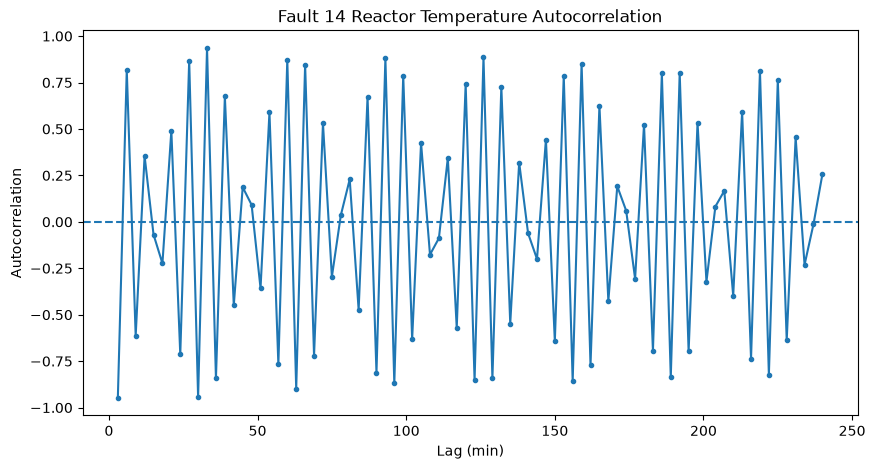

In [91]:
plt.figure(figsize=(10, 5))

plt.plot(
    acf_df["lag_min"],
    acf_df["autocorrelation"],
    marker="o",
    markersize=3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Lag (min)")
plt.ylabel("Autocorrelation")
plt.title("Fault 14 Reactor Temperature Autocorrelation")

plt.show()

In [92]:
acf_df["is_peak"] = (
    (acf_df["autocorrelation"] > acf_df["autocorrelation"].shift(1)) &
    (acf_df["autocorrelation"] > acf_df["autocorrelation"].shift(-1))
)

acf_peaks = acf_df[
    acf_df["is_peak"] &
    (acf_df["autocorrelation"] > 0)
]

acf_peaks[
    ["lag_min", "autocorrelation"]
]

,lag_min,autocorrelation
1,6,0.817552
3,12,0.354834
6,21,0.490371
8,27,0.868003
10,33,0.935850
12,39,0.676000
14,45,0.186394
17,54,0.589678
19,60,0.871868
21,66,0.846048


In [93]:
acf_peaks.nlargest(
    10,
    "autocorrelation"
)[
    ["lag_min", "autocorrelation"]
]

,lag_min,autocorrelation
10,33,0.935850
41,126,0.885270
30,93,0.879531
19,60,0.871868
8,27,0.868003
52,159,0.851622
21,66,0.846048
1,6,0.817552
72,219,0.813923
63,192,0.801781


In [94]:
temp_signal = (
    osc_zone["xmeas_9"]
    - osc_zone["xmeas_9"].mean()
)

In [95]:
fft_values = np.fft.rfft(temp_signal)

frequencies = np.fft.rfftfreq(
    len(temp_signal),
    d=3/60
)

In [96]:
amplitude = np.abs(fft_values)

In [97]:
dominant_idx = np.argmax(
    amplitude[1:]
) + 1

dominant_frequency = frequencies[dominant_idx]

dominant_period_h = (
    1 / dominant_frequency
)

dominant_period_min = (
    dominant_period_h * 60
)

print(
    "Dominant frequency:",
    dominant_frequency,
    "cycles/hour"
)

print(
    "Dominant period:",
    dominant_period_min,
    "min"
)

Dominant frequency: 9.083333333333332 cycles/hour
Dominant period: 6.605504587155965 min


In [98]:
control_ratio_f4 = (
    cumulative_control_deviation
    / normal_effort_mean
)

control_ratio_f14 = (
    control_burden_f14
    / normal_control_mean_f14
)

print("Fault 4 control ratio:", control_ratio_f4)
print("Fault 14 control ratio:", control_ratio_f14)

Fault 4 control ratio: 8.337414904373789
Fault 14 control ratio: 15.602109171790127


In [99]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Recovery Time (min)",
        "Settling Time (min)",
        "In-range Ratio (%)",
        "IAE (°C·h)",
        "ISE (°C²·h)",
        "Control Burden",
        "Control Burden / Normal"
    ],

    "Fault 4": [
        round(recovery_minutes, 1),
        round(settling_time_min, 1),
        round(f4_ratio, 1),
        round(IAE_fault, 4),
        round(ISE_fault, 5),
        round(cumulative_control_deviation, 3),
        round(control_ratio_f4, 2)
    ],

    "Fault 14": [
        round(recovery_minutes_f14, 1),
        "Not settled",
        round(f14_ratio, 1),
        round(IAE_f14, 4),
        round(ISE_f14, 5),
        round(control_burden_f14, 3),
        round(control_ratio_f14, 2)
    ]
})

comparison_df

,Metric,Fault 4,Fault 14
0,Recovery Time (min),3.00000,9.0
1,Settling Time (min),57.00000,Not settled
2,In-range Ratio (%),77.50000,2.5
3,IAE (°C·h),0.04940,0.4415
4,ISE (°C²·h),0.00333,0.1213
5,Control Burden,7.36400,12.679
6,Control Burden / Normal,8.34000,15.6


In [100]:
normal_2h_iae_f14 = []
normal_2h_ise_f14 = []

for start_h in [0, 2, 4, 6]:

    normal_window_f14 = df_f14[
        (df_f14["time_h"] >= start_h) &
        (df_f14["time_h"] < start_h + 2)
    ]

    iae_f14_normal = (
        normal_window_f14["abs_temp_error"] * dt_h
    ).sum()

    ise_f14_normal = (
        normal_window_f14["squared_temp_error"] * dt_h
    ).sum()

    normal_2h_iae_f14.append(iae_f14_normal)
    normal_2h_ise_f14.append(ise_f14_normal)

In [101]:
normal_iae_mean_f14 = np.mean(normal_2h_iae_f14)
normal_ise_mean_f14 = np.mean(normal_2h_ise_f14)

print("Fault 14 mean normal IAE:", normal_iae_mean_f14)
print("Fault 14 mean normal ISE:", normal_ise_mean_f14)

Fault 14 mean normal IAE: 0.029284374999996567
Fault 14 mean normal ISE: 0.0006899687500000499


In [102]:
iae_ratio_f14 = IAE_f14 / normal_iae_mean_f14
ise_ratio_f14 = ISE_f14 / normal_ise_mean_f14

print("Fault 4 IAE / Normal:", iae_ratio)
print("Fault 14 IAE / Normal:", iae_ratio_f14)

print("Fault 4 ISE / Normal:", ise_ratio)
print("Fault 14 ISE / Normal:", ise_ratio_f14)

Fault 4 IAE / Normal: 1.6619496028195042
Fault 14 IAE / Normal: 15.075445523425236
Fault 4 ISE / Normal: 4.559409065137425
Fault 14 ISE / Normal: 175.8078264414025


In [103]:
normalized_df = pd.DataFrame({
    "Metric": [
        "IAE",
        "ISE",
        "Control Burden"
    ],

    "Fault 4": [
        iae_ratio,
        ise_ratio,
        control_ratio_f4
    ],

    "Fault 14": [
        iae_ratio_f14,
        ise_ratio_f14,
        control_ratio_f14
    ]
})

normalized_df

,Metric,Fault 4,Fault 14
0,IAE,1.661950,15.075446
1,ISE,4.559409,175.807826
2,Control Burden,8.337415,15.602109


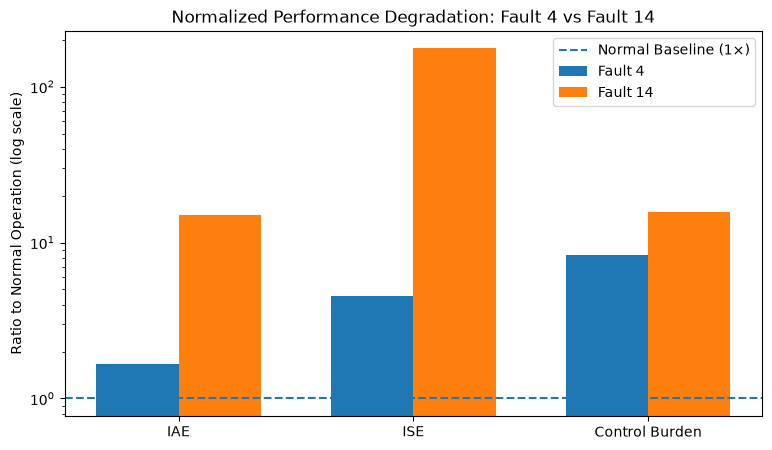

In [105]:
x = np.arange(len(normalized_df["Metric"]))
width = 0.35

plt.figure(figsize=(9, 5))

bars_f4 = plt.bar(
    x - width/2,
    normalized_df["Fault 4"],
    width,
    label="Fault 4"
)

bars_f14 = plt.bar(
    x + width/2,
    normalized_df["Fault 14"],
    width,
    label="Fault 14"
)

plt.axhline(
    1,
    linestyle="--",
    label="Normal Baseline (1×)"
)

plt.yscale("log")

plt.xticks(
    x,
    normalized_df["Metric"]
)

plt.ylabel("Ratio to Normal Operation (log scale)")
plt.title("Normalized Performance Degradation: Fault 4 vs Fault 14")

plt.legend()

plt.savefig(
    "images/09_normalized_fault_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()